In [60]:
import base64
import time

from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.agents.middleware import (
    HumanInTheLoopMiddleware,
    LLMToolEmulator,
    LLMToolSelectorMiddleware,
    ModelCallLimitMiddleware,
    ModelFallbackMiddleware,
    PIIMiddleware,
    SummarizationMiddleware,
    TodoListMiddleware,
    ToolCallLimitMiddleware,
    ToolRetryMiddleware,
)
from langchain.messages import AIMessage, HumanMessage
from langchain.tools import tool
from langchain_mistralai import ChatMistralAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command

load_dotenv()

True

In [2]:
@tool
def calculator_tool(expression: str) -> str:
    """ Use this tool to evaluate math expressions. """
    return str(eval(expression))

@tool
def get_weather(location: str) -> str:
    """ Use this tool to get the weather for a specific location. """
    return {'location': location, 'weather': 'sunny', 'temperature': '25°C'}

# Summarization

In [20]:
agent= create_agent(
    model= 'mistral-medium-latest',
    tools= [calculator_tool, get_weather],
    checkpointer= InMemorySaver(),
    middleware= [
        SummarizationMiddleware(
            model= 'mistral-small-latest',
            trigger=[ # select from tokens used during generation ("tokens"), total messages ("messages"), fraction of context window for model occupied ("fraction").
                ("tokens", 1000),
                ("messages", 13),
                ("fraction", 0.9)
            ],
            keep= ("messages", 7)
        ),
    ]
)

config= {"configurable": {"thread_id": "1"}}

In [21]:
agent.invoke({"messages": "hi, my name is bob"}, config)
agent.invoke({"messages": "write a poem about cats in 900 tokens"}, config)
agent.invoke({"messages": "now do the same but for dogs"}, config)
agent.invoke({"messages": "Suggest a suitable name for both the poems"}, config)
agent.invoke({"messages": "Now, kindly tell me about the weather in India"}, config)
agent.invoke({"messages": "What is the result of 5 multiplied by 5?"}, config)
final_response = agent.invoke({"messages": "what's my name?"}, config)

final_response["messages"][-1].pretty_print()

================================== Ai Message ==================================

I don’t have access to personal information about you, including your name. If you’d like, you can tell me your name, and I’ll be happy to address you by it! 😊


In [22]:
final_response

{'messages': [HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\nThe user requested two poems: one about cats (already completed) and another about dogs.\n\n## SUMMARY\n- The user asked for a 900-token poem about cats, which was provided.\n- The user then requested a similar poem about dogs, which was also provided.\n- No specific preferences or constraints were given for either poem.\n\n## ARTIFACTS\n- **Cats Poem**: "Ode to the Whiskered Wanderers" (900 tokens)\n- **Dogs Poem**: "Ode to the Loyal Hearts" (900 tokens)\n\n## NEXT STEPS\n- No further tasks remain. The user\'s requests have been fulfilled.', additional_kwargs={'lc_source': 'summarization'}, response_metadata={}, id='61350abc-4ff0-4dea-b073-2246e061f75a'),
  HumanMessage(content='Suggest a suitable name for both the poems', additional_kwargs={}, response_metadata={}, id='52fda802-2fd2-4c7d-b126-c9f3dfd3e38c'),
  AIMessage(content='For your cat poem, a suitable name could be:\n**"Whi

# Human in the Loop

In [55]:
agent= create_agent(
    model= 'mistral-medium-latest',
    tools= [calculator_tool, get_weather],
    system_prompt= 'You are a helpful assistant. You have access to certain tools, use them whenecer necessary. If a tool exists, do not use your own knowledge to answer questions.',
    checkpointer= InMemorySaver(),
    middleware= [
        HumanInTheLoopMiddleware(
            interrupt_on={
                "calculator_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "get_weather": False,
            }
        ),
    ]
)

config= {"configurable": {"thread_id": "1"}}

In [58]:
final_response= agent.invoke({'messages': [HumanMessage(content='What is 255 divided by 5?')]}, config)

final_response["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  calculator_tool (1TDJ99M5F)
 Call ID: 1TDJ99M5F
  Args:
    expression: 255 / 5


In [59]:
final_response

{'messages': [HumanMessage(content='How is the weather in India?', additional_kwargs={}, response_metadata={}, id='7836d9bc-f58f-4663-8956-3e033be95e00'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'K947MWhzP', 'function': {'name': 'get_weather', 'arguments': '{"location": "India"}'}, 'index': 0}]}, response_metadata={'token_usage': {'prompt_tokens': 170, 'total_tokens': 182, 'completion_tokens': 12, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'mistral-medium-latest', 'model': 'mistral-medium-latest', 'finish_reason': 'tool_calls', 'model_provider': 'mistralai'}, id='lc_run--019ce14f-c4d7-73b3-80fa-99077a83490a-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'India'}, 'id': 'K947MWhzP', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 170, 'output_tokens': 12, 'total_tokens': 182}),
  ToolMessage(content='{"location": "India", "weather": "sunny", "temperature": "25°C"}', name='get_weather', id='b0c210a4-7

In [60]:
# continuing from interrupt

result= agent.invoke(
    Command(resume= {
        'decisions' : [{
            'type': 'approve'
        }]
    }),
    config
)

result['messages'][-1].pretty_print()

================================== Ai Message ==================================

The result of **255 divided by 5** is **51**.


In [61]:
result

{'messages': [HumanMessage(content='How is the weather in India?', additional_kwargs={}, response_metadata={}, id='7836d9bc-f58f-4663-8956-3e033be95e00'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'K947MWhzP', 'function': {'name': 'get_weather', 'arguments': '{"location": "India"}'}, 'index': 0}]}, response_metadata={'token_usage': {'prompt_tokens': 170, 'total_tokens': 182, 'completion_tokens': 12, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'mistral-medium-latest', 'model': 'mistral-medium-latest', 'finish_reason': 'tool_calls', 'model_provider': 'mistralai'}, id='lc_run--019ce14f-c4d7-73b3-80fa-99077a83490a-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'India'}, 'id': 'K947MWhzP', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 170, 'output_tokens': 12, 'total_tokens': 182}),
  ToolMessage(content='{"location": "India", "weather": "sunny", "temperature": "25°C"}', name='get_weather', id='b0c210a4-7

In [62]:
result= agent.invoke({'messages': [HumanMessage(content='What is the result of 2555 divided by 5?')]}, config)
result['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  calculator_tool (0bpDYvyKF)
 Call ID: 0bpDYvyKF
  Args:
    expression: 2555 / 5


In [63]:
result

{'messages': [HumanMessage(content='How is the weather in India?', additional_kwargs={}, response_metadata={}, id='7836d9bc-f58f-4663-8956-3e033be95e00'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'K947MWhzP', 'function': {'name': 'get_weather', 'arguments': '{"location": "India"}'}, 'index': 0}]}, response_metadata={'token_usage': {'prompt_tokens': 170, 'total_tokens': 182, 'completion_tokens': 12, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'mistral-medium-latest', 'model': 'mistral-medium-latest', 'finish_reason': 'tool_calls', 'model_provider': 'mistralai'}, id='lc_run--019ce14f-c4d7-73b3-80fa-99077a83490a-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'India'}, 'id': 'K947MWhzP', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 170, 'output_tokens': 12, 'total_tokens': 182}),
  ToolMessage(content='{"location": "India", "weather": "sunny", "temperature": "25°C"}', name='get_weather', id='b0c210a4-7

In [64]:
result= agent.invoke(
    Command(resume= {
        'decisions' : [{
            'type': 'edit',
            'edited_action': {
                'name': 'calculator_tool',
                'args': {
                    'expression': '2555 / 35'
                }
            }
        }]
    }),
    config
)

result['messages'][-1].pretty_print()

================================== Ai Message ==================================

The result of **2555 divided by 35** is **73**. It seems I made a mistake earlier. Did you mean **2555 divided by 35** or **2555 divided by 5**? Let me correct it.
Tool Calls:
  calculator_tool (2RHiJrfn7)
 Call ID: 2RHiJrfn7
  Args:
    expression: 2555 / 5


In [65]:
result

{'messages': [HumanMessage(content='How is the weather in India?', additional_kwargs={}, response_metadata={}, id='7836d9bc-f58f-4663-8956-3e033be95e00'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'K947MWhzP', 'function': {'name': 'get_weather', 'arguments': '{"location": "India"}'}, 'index': 0}]}, response_metadata={'token_usage': {'prompt_tokens': 170, 'total_tokens': 182, 'completion_tokens': 12, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'mistral-medium-latest', 'model': 'mistral-medium-latest', 'finish_reason': 'tool_calls', 'model_provider': 'mistralai'}, id='lc_run--019ce14f-c4d7-73b3-80fa-99077a83490a-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'India'}, 'id': 'K947MWhzP', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 170, 'output_tokens': 12, 'total_tokens': 182}),
  ToolMessage(content='{"location": "India", "weather": "sunny", "temperature": "25°C"}', name='get_weather', id='b0c210a4-7

In [66]:
result= agent.invoke(
    Command(resume= {
        'decisions' : [{
            'type': 'approve'
        }]
    }),
    config
)

result['messages'][-1].pretty_print()

================================== Ai Message ==================================

The result of **2555 divided by 5** is **511**.


# Model Call Limit

In [77]:
agent= create_agent(
    model= 'mistral-medium-latest',
    tools= [calculator_tool, get_weather],
    system_prompt= 'You are a helpful assistant. You have access to certain tools, use them whenecer necessary. If a tool exists, do not use your own knowledge to answer questions.',
    checkpointer= InMemorySaver(),
    middleware= [
        ModelCallLimitMiddleware(
            thread_limit=6,
            run_limit= 3,
            exit_behavior= "end"
        )
    ]
)

config= {"configurable": {"thread_id": "1"}}

In [78]:
final_response =agent.invoke({"messages": "hi, my name is bob"}, config)
print(final_response["messages"][-1].pretty_print())

final_response =agent.invoke({"messages": "write a poem about cats in 90 tokens"}, config)
print(final_response["messages"][-1].pretty_print())

final_response =agent.invoke({"messages": "now do the same but for dogs"}, config)
print(final_response["messages"][-1].pretty_print())

final_response =agent.invoke({"messages": "Suggest a suitable name for both the poems"}, config)
print(final_response["messages"][-1].pretty_print())

final_response =agent.invoke({"messages": "Now, kindly tell me about the weather in India"}, config)
print(final_response["messages"][-1].pretty_print())

final_response =agent.invoke({"messages": "What is the result of 5 multiplied by 5?"}, config)
print(final_response["messages"][-1].pretty_print())

final_response = agent.invoke({"messages": "what's my name?"}, config)
print(final_response["messages"][-1].pretty_print())

================================== Ai Message ==================================

Hello, Bob! How can I assist you today?
None
================================== Ai Message ==================================

In moonlit beams, they softly tread,
Eyes like embers, whiskers spread.
Silent paws on floors they glide,
Mysteries deep they hide inside.

Purring songs of warmth and grace,
Curled in sunlit, cozy space.
Claws like lace, yet fierce their might,
Guardians of the quiet night.

With every leap, a dance so free,
Cats weave dreams for you and me.
None
================================== Ai Message ==================================

Fur and wag, a boundless joy,
Loyal heart, a faithful ploy.
Eyes so bright, a love so true,
Every day they shine anew.

Paws that race through field and stream,
Chasing dreams in sunlit gleam.
Bark like song, a warm embrace,
Dogs fill life with endless grace.
None
================================== Ai Message ==================================

For the **ca

In [82]:
final_response

{'messages': [HumanMessage(content='hi, my name is bob', additional_kwargs={}, response_metadata={}, id='7bd24d43-1231-4e29-ad34-7013213a7767'),
  AIMessage(content='Hello, Bob! How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'prompt_tokens': 169, 'total_tokens': 181, 'completion_tokens': 12, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'mistral-medium-latest', 'model': 'mistral-medium-latest', 'finish_reason': 'stop', 'model_provider': 'mistralai'}, id='lc_run--019ce165-b478-7dd3-838a-5a5016452cbd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 169, 'output_tokens': 12, 'total_tokens': 181}),
  HumanMessage(content='write a poem about cats in 90 tokens', additional_kwargs={}, response_metadata={}, id='e60baab8-a929-4065-be9e-59c95a21adc3'),
  AIMessage(content='In moonlit beams, they softly tread,\nEyes like embers, whiskers spread.\nSilent paws on floors they glide,\nMysteries deep they hide inside.\n\n

# Tool Call Limit

In [101]:
agent= create_agent(
    model= 'mistral-medium-2508',
    tools= [calculator_tool, get_weather],
    system_prompt= 'You are a helpful assistant. You have access to certain tools, use them whenecer necessary. If a tool exists, do not use your own knowledge to answer questions.',
    checkpointer= InMemorySaver(),
    middleware= [
        ToolCallLimitMiddleware(thread_limit=5, run_limit=5, exit_behavior= "end"), # for all tools
        ToolCallLimitMiddleware(
            tool_name="calculator_tool", # for  specific tool
            thread_limit=3,
            run_limit=3,
            exit_behavior= "end"
        ),
    ],
)

config= {"configurable": {"thread_id": "1"}}

In [102]:
final_response =agent.invoke({"messages": "What is the result of 5 multiplied by 5?"}, config)
print(final_response["messages"][-1].pretty_print())
time.sleep(1)
final_response =agent.invoke({"messages": "What is the result of 5 multiplied by 10?"}, config)
print(final_response["messages"][-1].pretty_print())
time.sleep(1)
final_response =agent.invoke({"messages": "What is the result of 5 multiplied by 15?"}, config)
print(final_response["messages"][-1].pretty_print())
time.sleep(1)
final_response =agent.invoke({"messages": "What is the result of 5 multiplied by 20?"}, config)
print(final_response["messages"][-1].pretty_print())
time.sleep(1)
final_response =agent.invoke({"messages": "Now, kindly tell me about the weather in India"}, config)
print(final_response["messages"][-1].pretty_print())
time.sleep(1)
final_response =agent.invoke({"messages": "What is the result of 5 multiplied by 25?"}, config)
print(final_response["messages"][-1].pretty_print())
time.sleep(1)
final_response = agent.invoke({"messages": "Now, kindly tell me about the weather in Bihar"}, config)
print(final_response["messages"][-1].pretty_print())

================================== Ai Message ==================================

The result of \(5 \times 5\) is **25**.
None
================================== Ai Message ==================================

The result of \(5 \times 10\) is **50**.
None
================================== Ai Message ==================================

The result of \(5 \times 15\) is **75**.
None
================================== Ai Message ==================================

'calculator_tool' tool call limit reached: thread limit exceeded (4/3 calls).
None
================================== Ai Message ==================================

The weather in **India** is currently **sunny** with a temperature of **25°C**.
None
================================== Ai Message ==================================

The result of \(5 \times 25\) is **125**.
None
================================== Ai Message ==================================

The weather in **Bihar** is currently **sunny** with a temperature of **25

In [103]:
final_response

{'messages': [HumanMessage(content='What is the result of 5 multiplied by 5?', additional_kwargs={}, response_metadata={}, id='b8a93f69-9240-40b7-8b74-869f1f08004c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '01ogFzPxE', 'function': {'name': 'calculator_tool', 'arguments': '{"expression": "5 * 5"}'}, 'index': 0}]}, response_metadata={'token_usage': {'prompt_tokens': 175, 'total_tokens': 191, 'completion_tokens': 16, 'prompt_tokens_details': {'cached_tokens': 144}}, 'model_name': 'mistral-medium-2508', 'model': 'mistral-medium-2508', 'finish_reason': 'tool_calls', 'model_provider': 'mistralai'}, id='lc_run--019ce17a-3c2e-7b40-9020-8dc4a2f6c23f-0', tool_calls=[{'name': 'calculator_tool', 'args': {'expression': '5 * 5'}, 'id': '01ogFzPxE', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 175, 'output_tokens': 16, 'total_tokens': 191}),
  ToolMessage(content='25', name='calculator_tool', id='767de845-3a66-4da2-86b4-e17a1b9bd53a', tool_ca

# Model Fallback 

In [18]:

model = ChatMistralAI(model="devstral-2512")
agent= create_agent(
    model=model,
    tools= [calculator_tool, get_weather],
    system_prompt= 'You are a helpful assistant. You have access to certain tools, use them whenecer necessary. If a tool exists, do not use your own knowledge to answer questions.',
    checkpointer= InMemorySaver(),
    middleware= [ModelFallbackMiddleware(
        'mistral-medium-2508'
    )]
)

config= {"configurable": {"thread_id": "1"}}

In [20]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

image_path = r"C:\Users\Lenovo\Downloads\Test_image.webp"
base64_image = encode_image(image_path)

In [21]:
Question="What is in this image?"
input={'messages':[
    {'role': 'user', 'content': Question},
    {'role': 'user', 'content': [{'type': 'image_url', "image_url": f"data:image/jpg;base64,{base64_image}"}]}
]}
config={'configurable': {'thread_id': '1'}}
response= agent.invoke(input, config)
print(response['messages'][-1].pretty_print())

================================== Ai Message ==================================

The image shows a plate of **Penne pasta** coated in a vibrant orange sauce. The sauce appears to be a **tomato-based sauce**, likely a classic **marinara** or **arrabbiata sauce**, which is commonly used in Italian cuisine. The pasta is garnished with **grated cheese**, possibly Parmesan, and **chopped fresh herbs**, likely parsley or basil. The dish looks delicious and is presented in a white bowl.
None


{'messages': [HumanMessage(content='What is in this image?', additional_kwargs={}, response_metadata={}, id='eef3b922-cae8-4f25-97bf-c1abb789f501'),
  HumanMessage(content=[{'type': 'image_url', 'image_url': ''}], additional_kwargs={}, response_metadata={}, id='85083ef0-a9c9-4530-b710-d6ad4c4d4894'),
  AIMessage(content='The image shows a plate of **Penne pasta** coated in a vibrant orange sauce. The sauce appears to be a **tomato-based sauce**, likely a classic **marinara** or **arrabbiata sauce**, which is commonly used in Italian cuisine. The pasta is garnished with **grated cheese**, possibly Parmesan, and **chopped fresh herbs**, likely parsley or basil. The dish looks delicious and is presented in a white bowl.', additional_kwargs={}, response_metadata={'token_usage': {'prompt_tokens': 1905, 'total_tokens': 2001, 'completion_tokens': 96, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'mistral-medium-2508', 'model': 'mistral-medium-2508', 'finish_reason': 'stop', 'm
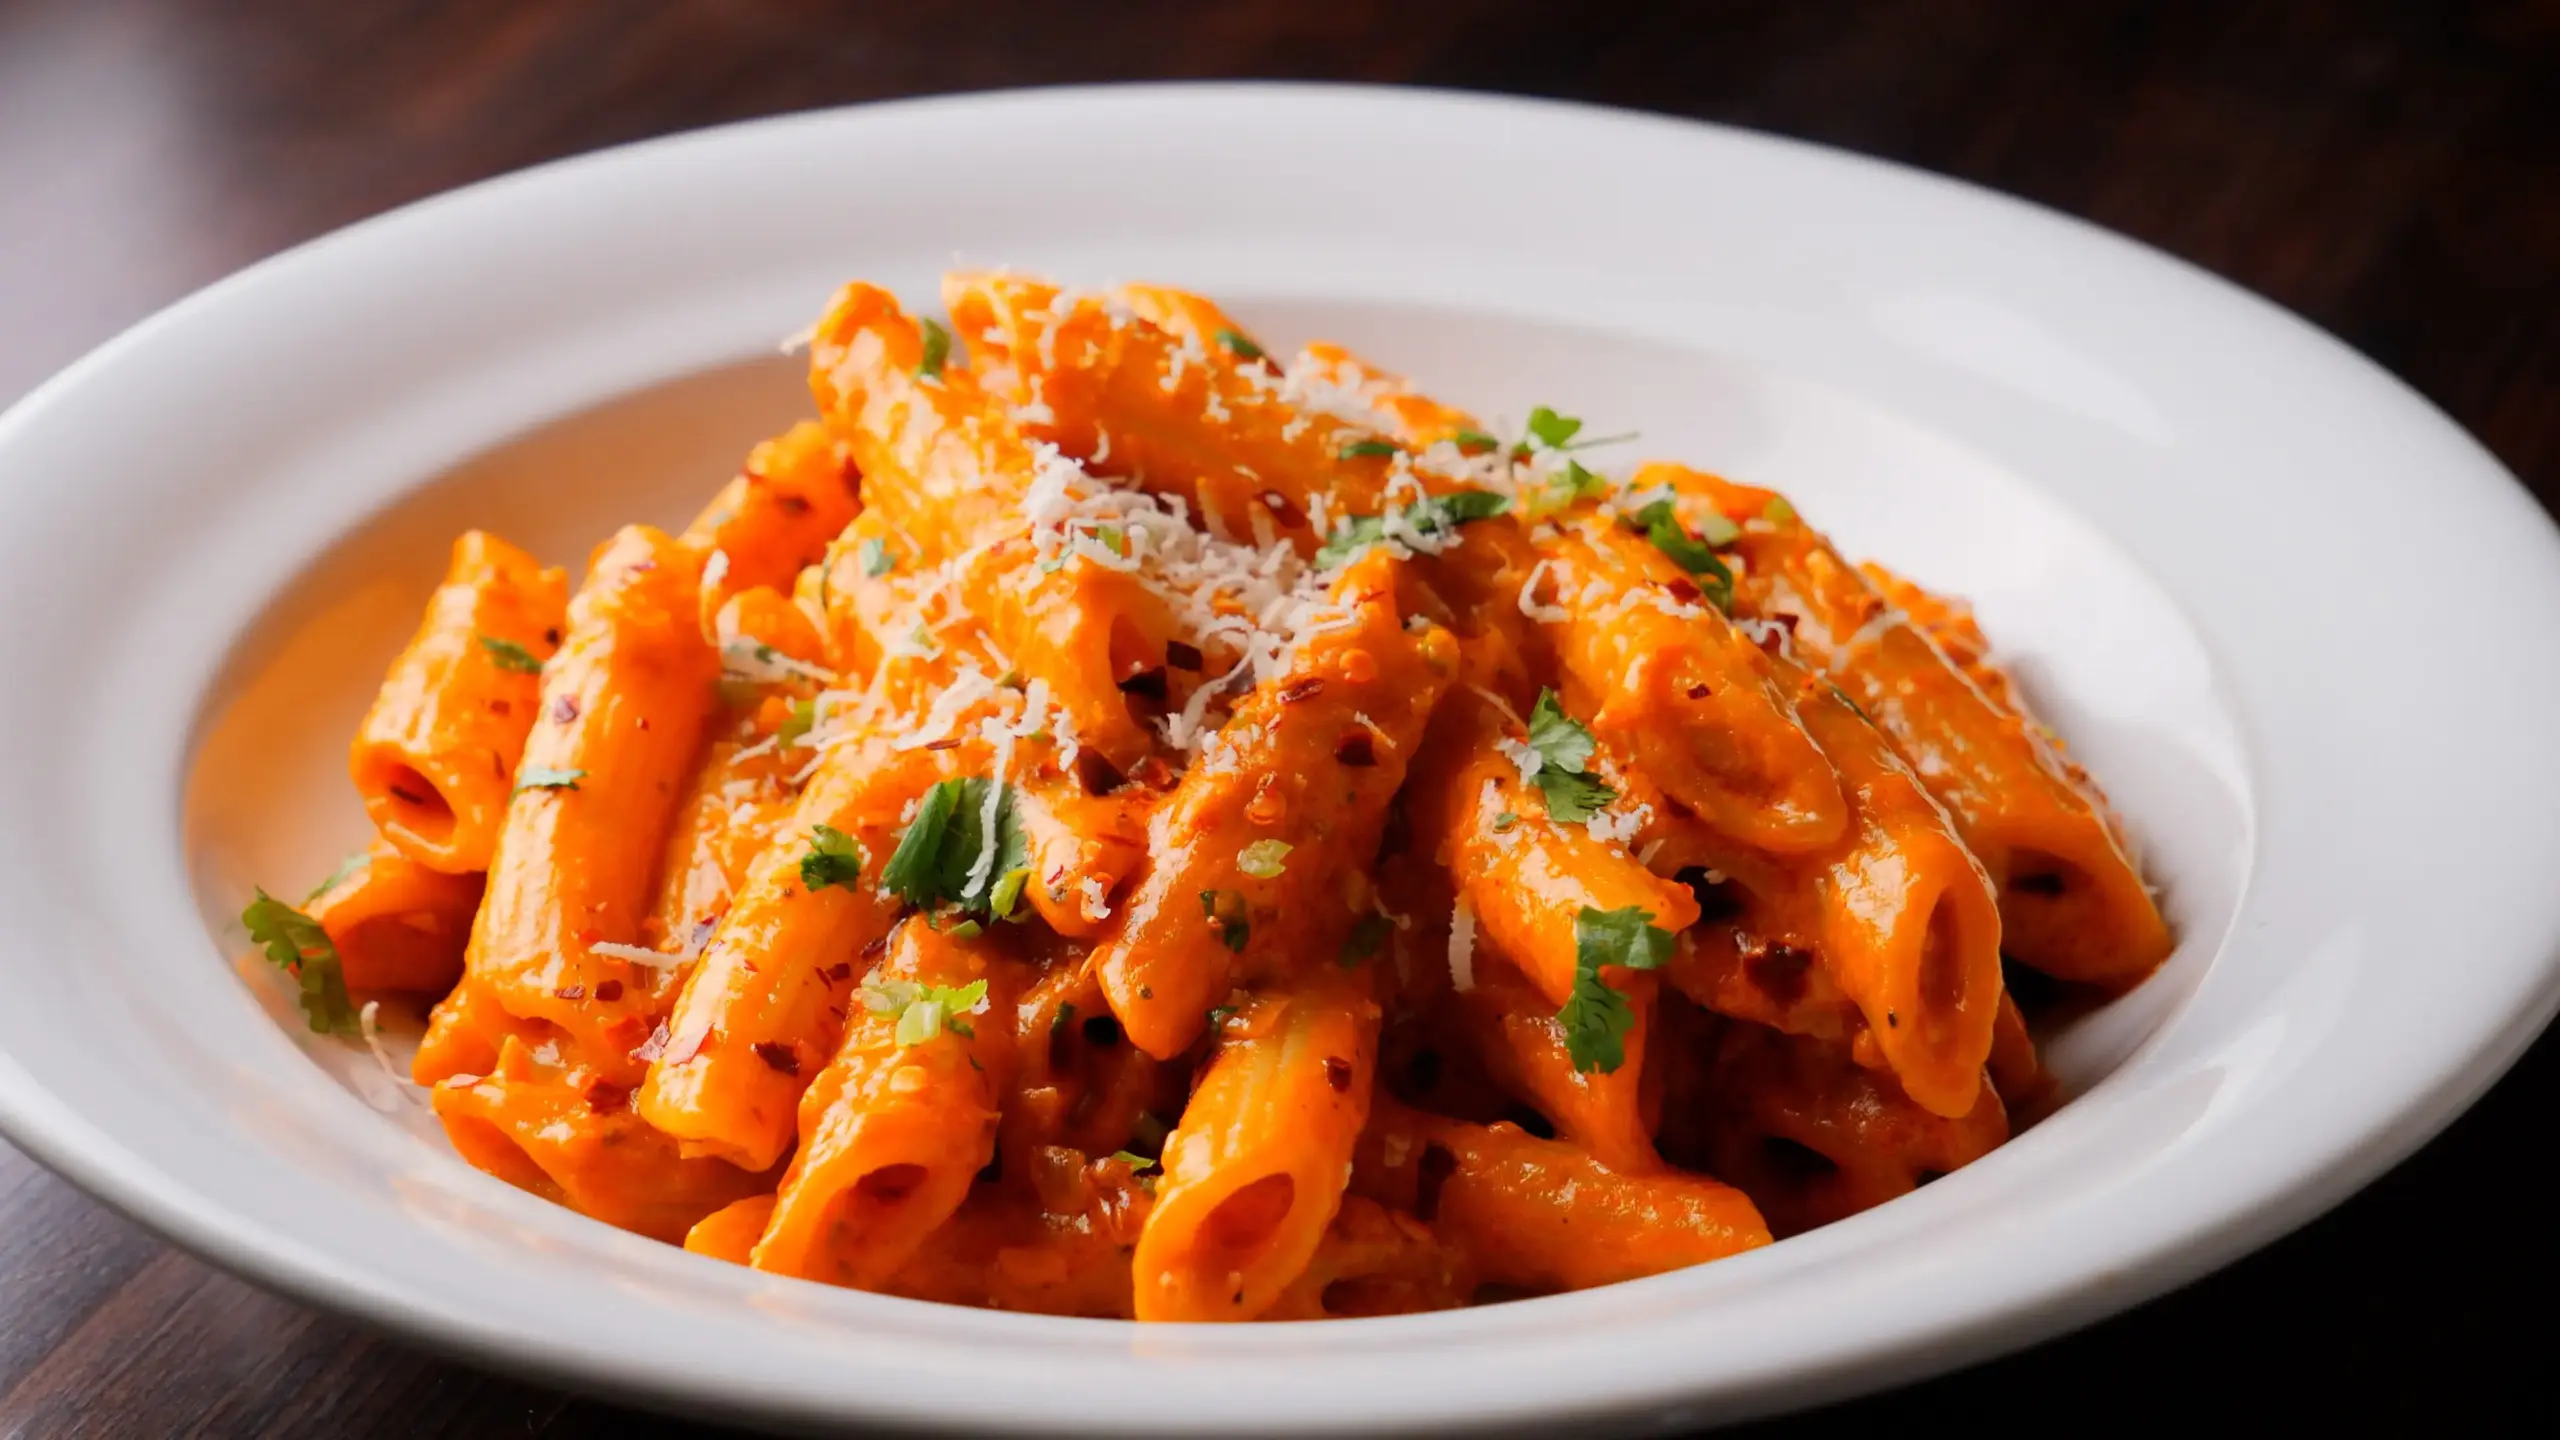

In [22]:
response

# Personal Identifiable information (PII)

In [26]:
agent= create_agent(
    model= 'mistral-medium-2508',
    tools= [calculator_tool, get_weather],
    checkpointer=InMemorySaver(),
    middleware= [
        PIIMiddleware("email", strategy="redact", apply_to_input=True, apply_to_output=False, apply_to_tool_results=False), # the boolean values reflecct default values
        PIIMiddleware('credit_card', strategy= "mask"),
        PIIMiddleware('ip', strategy= "mask"),
        PIIMiddleware('mac_address', strategy= "mask"),
        PIIMiddleware('url', strategy= "redact"),
    ]
)

config= {"configurable": {"thread_id": "1"}}

In [27]:
result= agent.invoke({
    'messages': HumanMessage(content='One of my client with email - client@company.com , credit_card number - 5200828282828210 , ip address - 73.238.38.228 , mac address - 6D:BE:F1:FB:87:5E and url where he is having issues - https://www.google.com/search?q=generate+a+fake+amc+address&sca_esv=d7a88be7d6242215&rlz=1C1YTUH_enIN1115IN1115&ei=OZyyaYiWDuj2seMP-_qfkQs&ved=0ahUKEwjIlqGCmpqTAxVoe2wGHXv9J7IQ4dUDCBE&uact=5&oq=generate+a+fake+amc+address&gs_lp=Egxnd3Mtd2l6LXNlcnAiG2dlbmVyYXRlIGEgZmFrZSBhbWMgYWRkcmVzc0jkCVC7BlipCHABeACQAQCYAcMBoAHfBKoBAzAuNLgBA8gBAPgBAZgCAqAC0QHCAgoQABiwAxjWBBhHwgIKECEYoAEYwwQYCpgDAIgGAZAGCJIHBTEuMC4xoAf0D7IHAzItMbgHygHCBwMyLTLIBwiACAA&sclient=gws-wiz-serp. Help me write a 2 sentence mail to him to convey my issue.')},
    config,                     
)
print(result['messages'][-1].pretty_print())

================================== Ai Message ==================================

Here’s a professional and concise email draft for your client:

---

**Subject:** Follow-Up on Your Recent Issue

Dear [Client's Name],

I hope this message finds you well. I wanted to inform you that we are actively investigating the issue you reported on [REDACTED_URL]. Could you please share more details or steps to reproduce the issue so we can assist you better?

Looking forward to your response.

Best regards,
[Your Name]
None


In [29]:
result= agent.invoke({
    'messages': HumanMessage(content='What were the exact values that were visible to you in my first prompt?')},
    config,                     
)
print(result['messages'][-1].pretty_print())

================================== Ai Message ==================================

In your first prompt, the **exact visible values** were:

1. **Email**: `[REDACTED_EMAIL]`
2. **Credit card number**: `************8210`
3. **IP address**: `*.*.*.228`
4. **MAC address**: `**:**:**:**:5E`
5. **URL**: `[REDACTED_URL]`
None


# ToDo List

In [ ]:
agent= create_agent(
    model='mistral-medium-latest',
    tools= [calculator_tool, get_weather],
    system_prompt= 'You are a helpful assistant. You have access to certain tools, use them whenecer necessary. If a tool exists, do not use your own knowledge to answer questions.',
    checkpointer= InMemorySaver(),
    middleware= [TodoListMiddleware()]
)

config= {"configurable": {"thread_id": "1"}}

In [ ]:
result= agent.invoke({'messages': [HumanMessage(content='Help me prepare for an exam.')]},
    config
    )

result['messages'][-1].pretty_print()

================================== Ai Message ==================================

Preparing for an exam requires a structured approach to ensure you cover all the necessary topics and maximize your understanding. Here’s how I can assist you:

### Steps to Prepare for Your Exam:
1. **Identify the Exam Topics**: What subjects or topics will be covered in the exam? Do you have a syllabus or study guide?
2. **Gather Study Materials**: Collect your notes, textbooks, past exams, or online resources related to the topics.
3. **Create a Study Plan**: Organize your study sessions by prioritizing topics based on difficulty and importance.
4. **Practice with Questions**: Use practice questions or past exams to test your understanding.
5. **Review Weak Areas**: Focus on areas where you feel less confident.
6. **Time Management**: Allocate specific time slots for each topic and stick to the schedule.
7. **Stay Healthy**: Ensure you get enough rest, eat well, and take breaks to stay focused.

### Ho

# LLM Tool Selection 

In [48]:
agent= create_agent(
    model= 'mistral-medium-2508',
    tools= [calculator_tool, get_weather],
    system_prompt= 'You are a helpful assistant. You have access to certain tools, use them whenecer necessary. If a tool exists, do not use your own knowledge to answer questions.',
    checkpointer= InMemorySaver(),
    middleware= [
        LLMToolSelectorMiddleware(
            model= 'mistral-small-latest',
            max_tools= 2,
            always_include= ['get_weather']
        )
    ],
)

config= {"configurable": {"thread_id": "1"}}

In [49]:
result= agent.invoke({'messages': [HumanMessage(content='I am planning to visit Vietnam. What do you think?')]},
    config
)

result['messages'][-1].pretty_print()

================================== Ai Message ==================================

Vietnam is a fantastic destination with a rich culture, stunning landscapes, and delicious food! Here are some highlights to consider for your trip:

### **Top Attractions:**
1. **Hanoi** – The capital city with a mix of French colonial architecture, ancient temples, and vibrant street life.
2. **Ha Long Bay** – A UNESCO World Heritage Site with breathtaking limestone islands and emerald waters.
3. **Hoi An** – A charming ancient town with lantern-lit streets, tailors, and a relaxed atmosphere.
4. **Ho Chi Minh City (Saigon)** – A bustling metropolis with historical sites like the War Remnants Museum and Cu Chi Tunnels.
5. **Sapa** – A mountainous region with terraced rice fields and ethnic minority villages.
6. **Da Nang** – A coastal city with beautiful beaches and the famous Golden Bridge.
7. **Phu Quoc** – A tropical island with white-sand beaches and luxury resorts.
8. **Hue** – The former imperial c

In [50]:
result

{'messages': [HumanMessage(content='I am planning to visit Vietnam. What do you think?', additional_kwargs={}, response_metadata={}, id='943c38ca-c515-4acf-aac2-0dc099912cbb'),
  AIMessage(content='Vietnam is a fantastic destination with a rich culture, stunning landscapes, and delicious food! Here are some highlights to consider for your trip:\n\n### **Top Attractions:**\n1. **Hanoi** – The capital city with a mix of French colonial architecture, ancient temples, and vibrant street life.\n2. **Ha Long Bay** – A UNESCO World Heritage Site with breathtaking limestone islands and emerald waters.\n3. **Hoi An** – A charming ancient town with lantern-lit streets, tailors, and a relaxed atmosphere.\n4. **Ho Chi Minh City (Saigon)** – A bustling metropolis with historical sites like the War Remnants Museum and Cu Chi Tunnels.\n5. **Sapa** – A mountainous region with terraced rice fields and ethnic minority villages.\n6. **Da Nang** – A coastal city with beautiful beaches and the famous Golde

# Tool Retry

In [57]:
agent= create_agent(
    model= 'mistral-medium-2508',
    tools= [calculator_tool, get_weather],
    system_prompt= 'You are a helpful assistant. You have access to certain tools, use them whenecer necessary. If a tool exists, do not use your own knowledge to answer questions.',
    checkpointer= InMemorySaver(),
    middleware= [
        ToolRetryMiddleware(
            max_retries=2,
            backoff_factor=2.0,
            initial_delay=1.0,
        ),
    ],
)

config= {"configurable": {"thread_id": "1"}}

In [58]:
result= agent.invoke(
    {'messages': [HumanMessage(content='What is the rsullt of 13 divided by 0')]},
    config,
)
result['messages'][-1].pretty_print()

================================== Ai Message ==================================

The result of dividing any number by zero is **undefined**. It is mathematically impossible to divide by zero.


In [59]:
result

{'messages': [HumanMessage(content='What is the rsullt of 13 divided by 0', additional_kwargs={}, response_metadata={}, id='f5e23de3-50e9-4037-9058-db084c1fbc82'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'EZn8QcZZb', 'function': {'name': 'calculator_tool', 'arguments': '{"expression": "13 / 0"}'}, 'index': 0}]}, response_metadata={'token_usage': {'prompt_tokens': 177, 'total_tokens': 194, 'completion_tokens': 17, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'mistral-medium-2508', 'model': 'mistral-medium-2508', 'finish_reason': 'tool_calls', 'model_provider': 'mistralai'}, id='lc_run--019ce1f4-b92b-7f63-b241-b559dbb59c43-0', tool_calls=[{'name': 'calculator_tool', 'args': {'expression': '13 / 0'}, 'id': 'EZn8QcZZb', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 177, 'output_tokens': 17, 'total_tokens': 194}),
  ToolMessage(content="Tool 'calculator_tool' failed after 3 attempts with ZeroDivisionError: division by

# LLM Tool Emulator

In [70]:
model = ChatMistralAI(model="mistral-small-latest")
agent= create_agent(
    model= 'mistral-medium-2508',
    tools= [calculator_tool, get_weather],
    system_prompt= 'You are a helpful assistant. You have access to certain tools, use them whenecer necessary. If a tool exists, do not use your own knowledge to answer questions.',
    checkpointer= InMemorySaver(),
    middleware= [LLMToolEmulator(model=model)],
)

config= {"configurable": {"thread_id": "1"}}

In [71]:
result= agent.invoke(
    {
        'messages': [HumanMessage(content='How is the weather in New Zealand with todays date?')]
    },
    config
)

result['messages'][-1].pretty_print()

================================== Ai Message ==================================

Here is the current weather in **New Zealand** as of **November 15, 2023**:

### **Current Weather**
- **Temperature**: 18.5°C
- **Conditions**: Partly cloudy with scattered showers
- **Humidity**: 72%
- **Wind Speed**: 15 km/h (Southwest)
- **Visibility**: Good

### **Forecast**
- **Next 24 Hours**: Increasing cloud cover with a chance of rain, especially in the northern regions.
- **Next 48 Hours**: Cooler temperatures with persistent showers, particularly in the western areas.


In [72]:
result

{'messages': [HumanMessage(content='How is the weather in New Zealand with todays date?', additional_kwargs={}, response_metadata={}, id='88013a27-5729-4c8b-aad6-97c17e55b38c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'dfJ0FbJyc', 'function': {'name': 'get_weather', 'arguments': '{"location": "New Zealand"}'}, 'index': 0}]}, response_metadata={'token_usage': {'prompt_tokens': 175, 'total_tokens': 188, 'completion_tokens': 13, 'prompt_tokens_details': {'cached_tokens': 144}}, 'model_name': 'mistral-medium-2508', 'model': 'mistral-medium-2508', 'finish_reason': 'tool_calls', 'model_provider': 'mistralai'}, id='lc_run--019ce1fe-54ee-7a50-81c6-63b244fdb041-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'New Zealand'}, 'id': 'dfJ0FbJyc', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 175, 'output_tokens': 13, 'total_tokens': 188}),
  ToolMessage(content='```json\n{\n  "location": "New Zealand",\n  "current_weather": {\n  

# Context Editing